In [3]:
import pandas as pd
import numpy as np

files = [
    '500m_ib_mol_enamine_block_with_true_blocks.parquet', '500m_ib_mol_enamine_block.parquet',
    '500m_ib_mol_zinc22_block_with_true_blocks.parquet', '500m_ib_mol_zinc22_block.parquet',
    '500m_zinc22_mol_enamine_block_with_true_blocks.parquet', '500m_zinc22_mol_enamine_block.parquet',
    '500m_zinc22_mol_zinc22_block_with_true_blocks.parquet', '500m_zinc22_mol_zinc22_block.parquet',
]

df = []
for f in files:
    tmp = pd.read_parquet(f)
    tmp['file'] = f
    df.append(tmp)

df = pd.concat(df)

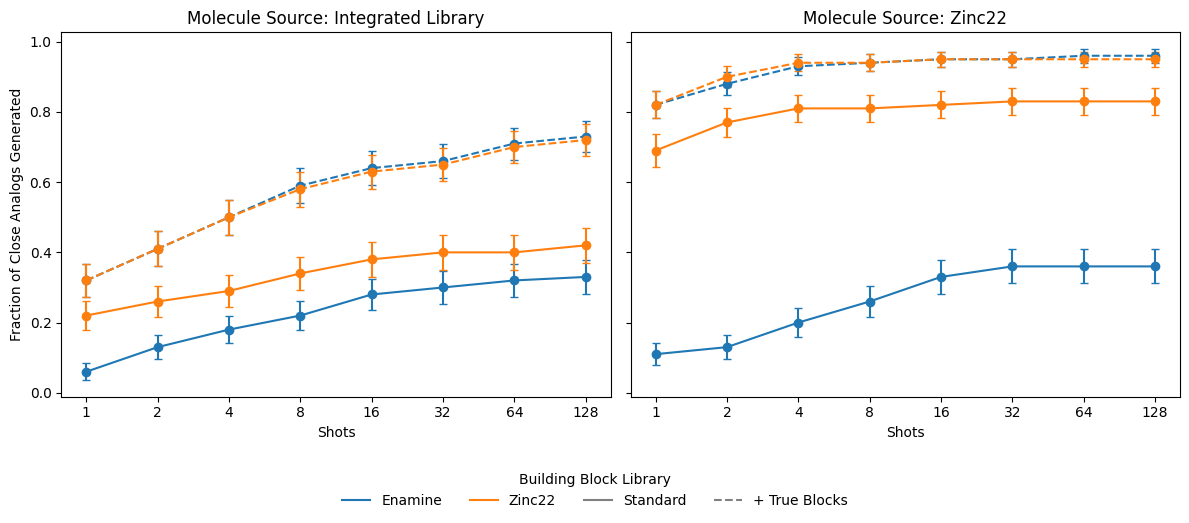

In [18]:
import matplotlib.pyplot as plt

# Parse file names into nice columns
def parse_file(f):
    mol_source = 'Integrated Library' if '_ib_mol_' in f else 'Zinc22'
    lib_source = 'Enamine' if '_enamine_' in f else 'Zinc22'
    has_truth = 'with_true_blocks' in f
    return mol_source, lib_source, has_truth

# Build results
results = []
for thresh in [1, 2, 4, 8, 16, 32, 64, 128]:
    new_df = df[df['shot_number'] < thresh]
    # Get per-molecule success (boolean)
    mol_success = (new_df.groupby(['file', 'source_smiles'])['tanimoto_sim'].max() > 0.85)
    # Compute mean and std error per file
    stats = mol_success.groupby('file').agg(['mean', 'std', 'count'])
    for f, row in stats.iterrows():
        mol_source, lib_source, has_truth = parse_file(f)
        se = row['std'] / np.sqrt(row['count'])
        results.append({'shots': thresh, 'perf': row['mean'], 'se': se, 'mol_source': mol_source, 'lib_source': lib_source, 'has_truth': has_truth})

results_df = pd.DataFrame(results)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors = {'Enamine': 'tab:blue', 'Zinc22': 'tab:orange'}
linestyles = {False: '-', True: '--'}

for ax, mol_src in zip(axes, ['Integrated Library', 'Zinc22']):
    sub = results_df[results_df['mol_source'] == mol_src]
    for lib in ['Enamine', 'Zinc22']:
        for has_truth in [False, True]:
            mask = (sub['lib_source'] == lib) & (sub['has_truth'] == has_truth)
            data = sub[mask].sort_values('shots')
            ax.errorbar(data['shots'], data['perf'], yerr=data['se'], color=colors[lib], linestyle=linestyles[has_truth], marker='o', capsize=3)
    ax.set_title(f'Molecule Source: {mol_src}')
    ax.set_xlabel('Shots')
    ax.set_xscale('log', base=2)
    ax.set_xticks([1, 2, 4, 8, 16, 32, 64, 128])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

axes[0].set_ylabel('Fraction of Close Analogs Generated')

# Single legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='tab:blue', label='Enamine'),
    Line2D([0], [0], color='tab:orange', label='Zinc22'),
    Line2D([0], [0], color='gray', linestyle='-', label='Standard'),
    Line2D([0], [0], color='gray', linestyle='--', label='+ True Blocks'),
]
fig.legend(handles=legend_elements, title='Building Block Library', loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4, frameon=False)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

In [9]:
df

,source_smiles_idx,source_smiles,synthesis_path,generated_smiles,valid,tanimoto_sim,shot_number,file
0,0,Cc1c(C(=O)Nc2ccc(C(C)C)cc2)sc2nc3n(c(=O)c12)CCC3,<ADD>Cc1c(C(=O)O)sc2nc3n(c(=O)c12)CCC3<ADD>O=C...,None,False,0.000000,0,500m_ib_mol_enamine_block_with_true_blocks.par...
1,0,Cc1c(C(=O)Nc2ccc(C(C)C)cc2)sc2nc3n(c(=O)c12)CCC3,<ADD>Cc1c(C(=O)O)sc2nc3n(c(=O)c12)CCC3<ADD>Nc1...,Cc1c(C(=O)Nc2ccc(C(C)C)cc2)sc2nc3n(c(=O)c12)CCC3,True,1.000000,1,500m_ib_mol_enamine_block_with_true_blocks.par...
2,0,Cc1c(C(=O)Nc2ccc(C(C)C)cc2)sc2nc3n(c(=O)c12)CCC3,<ADD>Cc1c(C(=O)O)sc2nc3n(c(=O)c12)CCC3<ADD>O=C...,None,False,0.000000,2,500m_ib_mol_enamine_block_with_true_blocks.par...
3,0,Cc1c(C(=O)Nc2ccc(C(C)C)cc2)sc2nc3n(c(=O)c12)CCC3,<ADD>Cc1c(C(=O)O)sc2nc3n(c(=O)c12)CCC3<ADD>Nc1...,Cc1c(C(=O)Nc2ccc(C(C)C)cc2)sc2nc3n(c(=O)c12)CCC3,True,1.000000,3,500m_ib_mol_enamine_block_with_true_blocks.par...
4,0,Cc1c(C(=O)Nc2ccc(C(C)C)cc2)sc2nc3n(c(=O)c12)CCC3,<ADD>Cc1c(C(=O)O)sc2nc3n(c(=O)c12)CCC3<ADD>O=C...,None,False,0.000000,4,500m_ib_mol_enamine_block_with_true_blocks.par...
...,...,...,...,...,...,...,...,...
12795,99,C=CCC(=O)N[C@@H]1[C@@H]2CCN(C(=O)[C@](C)(O)CC)...,<ADD>N[C@@H]1[C@H]2CCNC[C@@H]12<ADD>CC=CCC(=O)...,CC=CCC(=O)N[C@H]1[C@@H]2CN(C(=O)[C@@](C)(O)CC)...,True,0.746032,123,500m_zinc22_mol_zinc22_block.parquet
12796,99,C=CCC(=O)N[C@@H]1[C@@H]2CCN(C(=O)[C@](C)(O)CC)...,<ADD>N[C@@H]1[C@H]2CCNC[C@@H]12<ADD>CC=CCC(=O)...,CC=CCC(=O)N[C@H]1[C@@H]2CN(C(=O)[C@@](C)(O)CC)...,True,0.746032,124,500m_zinc22_mol_zinc22_block.parquet
12797,99,C=CCC(=O)N[C@@H]1[C@@H]2CCN(C(=O)[C@](C)(O)CC)...,<ADD>N[C@@H]1[C@H]2CCNC[C@@H]12<ADD>CC=CCC(=O)...,CC=CCC(=O)N[C@H]1[C@@H]2CN(C(=O)[C@@](C)(O)CC)...,True,0.746032,125,500m_zinc22_mol_zinc22_block.parquet
12798,99,C=CCC(=O)N[C@@H]1[C@@H]2CCN(C(=O)[C@](C)(O)CC)...,<ADD>N[C@@H]1[C@H]2CCNC[C@@H]12<ADD>C=CCC(=O)O...,C=CCC(=O)N[C@H]1[C@@H]2CN(C(=O)[C@@](C)(O)CC)C...,True,1.000000,126,500m_zinc22_mol_zinc22_block.parquet


In [ ]:
import pandas as pd
import numpy as np
df = pd.read_parquet('seno_enamine_blocks.parquet')

In [ ]:
df

,synthesis_path,smiles,logit_mean,logit_std
0,<ADD>O=C(Cl)c1cc(Cl)ccc1Cl<ADD>Cl.Cl.NC1CNCCC1...,Cc1c(Br)cc(C(=O)N2CCC(F)C(NC(=O)c3cc(Cl)ccc3Cl...,-0.173437,1.134413
1,<ADD>Clc1ncc2cc(Br)ccc2n1<ADD>Cl.O=C(O)[C@H]1C...,O=C(Nc1nc(Cl)ccc1I)[C@H]1CC(F)(F)CN1c1ncc2cc(B...,-0.341406,1.723197
2,<ADD>Cl.NCc1cccc2cc[nH]c12<ADD>CCCCC(C)CCBr<RX...,CCCCC(C)CCN(Cc1cccc2cc[nH]c12)C(=O)Cc1ccc(C)s1,-2.103259,1.377451
3,<ADD>CC(C)(CN)NC(=O)OC(C)(C)C<ADD>CCCCCCCCCC(C...,CCCCCCCCCC(CC)C(=O)NCC(C)(C)NC(=O)OC(C)(C)C,-4.131250,0.376248
4,<ADD>Cc1cc(C(=O)O)c(F)cc1F<ADD>Cl.Cl.NCC1CCC(N...,CCCCCCCCC(C)C(=O)NC1CCC(CNC(=O)c2cc(C)c(F)cc2F...,-1.563965,0.873431
...,...,...,...,...
336,<ADD>CC1CNCC(N)C1<ADD>F[B-](F)(F)CBr.[K+]<RXN>...,Cc1ccccc1NC(=O)NC1CC(C)CN(Cc2cc(O)cc(Br)c2)C1,-0.615234,2.422763
337,<ADD>Cl.O=C(O)[C@H]1CNCC[C@H]1O<ADD>CCc1cc(Br)...,CCc1cc(Br)ccc1NC(=O)[C@H]1CN(Cc2ccc(F)c(F)c2F)...,-2.561719,1.980173
338,<ADD>Cc1ccc2sc(Cl)nc2c1<ADD>Cl.Cl.NC1CNCCC1F<R...,CCC(C)CCCCC(=O)N(c1nc2cc(C)ccc2s1)C1CNCCC1F,-1.433496,1.306768
339,<ADD>Cc1cc(Br)cc(C)c1CBr<ADD>N[C@H]1CC[C@@H](C...,Cc1ccc(NC(=O)[C@H]2CC[C@@H](NCc3c(C)cc(Br)cc3C...,1.589136,1.779591


: 